# Machine learning for fault diagnosis: the whole training process

This notebook walks through every stage of the learned fault classifier, end to end, on the
simulator's own telemetry:

1. **Generate** a training matrix, with each fault's target and onset re-drawn per seed, and each cell simulated
   twice: on the full cluster and under a re-drawn subset allocation
2. **Label** windows from the injector's own event, never from the yaml
3. **Engineer** dimensionless, fleet-relative features per window, per GPU and per rack
4. **Split** by seed, and check for leakage with a label-permutation test
5. **Train** gradient-boosted trees and a linear baseline; evaluate on held-out seeds
6. **Transfer**: hold out a whole mesh, and train on full-cluster jobs only
7. **Ablate** feature families
8. **Stream**: score trailing windows and measure time to detect
9. **Compare** with the rule-based `metrics.diagnose` at run level
10. **Localise** the faulty GPU or rack as a ranking task
11. **Interpret** with permutation importance
12. **Unsupervised** baselines, and where they go blind

Nothing here modifies the simulator. The notebook imports `scripts/ml_baseline.py`, which does all of
its randomisation in memory by rebuilding the frozen config dataclasses, and every model is fitted live
in this notebook. The one expensive step, simulating 360 runs, is skipped when the cached dataset in
`runs_ml/` already exists; the cell that would run it is still here and shows the command.

Companion material: `ML_FAULT_DIAGNOSIS.pdf` (the slide deck built from the same pipeline) and
`scripts/ml_baseline_metrics.json` (the committed metrics the deck was rendered from).

In [1]:
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# locate the repo root from wherever this notebook is opened
ROOT = Path.cwd().resolve()
while not (ROOT / "scripts" / "ml_baseline.py").exists():
    assert ROOT.parent != ROOT, "run this notebook from inside the repository"
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))

import ml_baseline as mb           # the pipeline; it puts src/ on sys.path itself
from gcsim.config import load_config
from gcsim.scenarios import run_scenario
from gcsim.telemetry import read_run

RUNS = ROOT / "runs_ml"            # gitignored dataset directory
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160, "display.max_columns", 30, "display.precision", 3)

# the deck's palette: orange for faults / emphasis, teal for the model, blue for baselines
A, B, C, INK3 = "#c2410c", "#0f766e", "#1e40af", "#8a807a"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": False, "font.size": 9})
print("repo:", ROOT)
print("classes:", mb.CLASSES)

repo: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\GPU Cluster Simulator\GPU Cluster Simulator
classes: ['healthy', 'straggler', 'network_domain', 'thermal', 'gpu_degradation', 'phase_change']


## 1. What we are classifying

Six scenarios, four of them faults. The two non-faults matter as much as the faults: `phase_change`
costs 10 % of throughput with perfectly healthy hardware, which is exactly the case a naive
"is it slower?" detector gets wrong.

In [2]:
bundle = load_config()
rows = []
for name in bundle.scenario_order:
    sc = bundle.scenarios[name]
    inj = sc.injections[0] if sc.injections else None
    rows.append({"scenario": name, "fault": sc.fault, "tier": sc.tier,
                 "injection": inj.type if inj else "-", "yaml onset": inj.at_iteration if inj else "-",
                 "yaml target": (inj.params.get("target") if inj else None) or "-"})
pd.DataFrame(rows)

,scenario,fault,tier,injection,yaml onset,yaml target
0,healthy,False,none,-,-,-
1,straggler,True,rank,gpu_throughput_episodes,1,-
2,network_domain,True,rack,leaf_uplink_failure,300,{'rack': 2}
3,thermal,True,rack,cooling_degrade,250,{'rack': 1}
4,gpu_degradation,True,gpu,gpu_reliability_degrade,350,"{'rack': 3, 'node': 1, 'gpu': 2}"
5,phase_change,False,workload,workload_output_change,500,-


## 2. Generate: re-draw the fault's target and onset per seed

The yaml fixes each fault: thermal on rack 1 at iteration 250, the network fault on rack 2 at 300, the
bad GPU at `r3n1g2` at 350. A model trained on those runs could learn *"rack 1 means thermal"* or
*"iteration 300 means network"* and score perfectly while learning nothing about the physics.

`variant_bundle` rebuilds the frozen `Injection`/`ScenarioConfig`/`ConfigBundle` dataclasses in
memory with a new target and onset drawn from the seed. The simulator source is untouched.

In [3]:
for seed in mb.DEFAULT_SEEDS[:5]:      # the first five of the ten training seeds
    for scenario in ("thermal", "network_domain", "gpu_degradation", "phase_change"):
        _, choice = mb.variant_bundle(bundle, scenario, seed, randomise=True)
        print(f"seed {seed:2d}  {scenario:16s} onset {choice['at_iteration']:4d}  target {choice['target']}")

seed 42  thermal          onset  425  target {'rack': 3}
seed 42  network_domain   onset  534  target {'rack': 3}
seed 42  gpu_degradation  onset  307  target {'rack': 0, 'node': 3, 'gpu': 2}
seed 42  phase_change     onset  565  target None
seed  1  thermal          onset  304  target {'rack': 2}
seed  1  network_domain   onset  310  target {'rack': 1}
seed  1  gpu_degradation  onset  384  target {'rack': 3, 'node': 3, 'gpu': 2}
seed  1  phase_change     onset  203  target None
seed  2  thermal          onset  407  target {'rack': 1}
seed  2  network_domain   onset  549  target {'rack': 3}
seed  2  gpu_degradation  onset  365  target {'rack': 1, 'node': 3, 'gpu': 1}
seed  2  phase_change     onset  562  target None
seed  3  thermal          onset  397  target {'rack': 1}
seed  3  network_domain   onset  491  target {'rack': 2}
seed  3  gpu_degradation  onset  433  target {'rack': 0, 'node': 3, 'gpu': 6}
seed  3  phase_change     onset  451  target None
seed  4  thermal          onset 

Let's simulate **one** run live, so every later stage can be shown on data produced in this notebook.
A medium-mesh run takes a few seconds. Seed 7 is not in the training matrix.

In [4]:
DEMO_SCENARIO, DEMO_MESH, DEMO_SEED = "thermal", "medium", 7
variant, choice = mb.variant_bundle(bundle, DEMO_SCENARIO, DEMO_SEED, randomise=True)
t0 = time.perf_counter()
demo = run_scenario(DEMO_SCENARIO, mesh=DEMO_MESH, seed=DEMO_SEED, bundle=variant, out_dir=None)
print(f"simulated {demo.run_id} in {time.perf_counter() - t0:.1f}s; re-drawn injection: {choice}")
print({k: v.shape for k, v in demo.frames.items()})

simulated thermal__medium__seed7 in 2.5s; re-drawn injection: {'type': 'cooling_degrade', 'at_iteration': 368, 'target': {'rack': 3}}
{'telemetry_gpu': (25600, 15), 'telemetry_node': (3200, 8), 'telemetry_nic': (6400, 15), 'telemetry_switch_port': (19200, 21), 'telemetry_switch_aggregate': (1200, 12), 'telemetry_storage': (200, 10), 'rank_performance': (128000, 11), 'job_performance': (1000, 19), 'events': (5085, 7)}


### The job's allocation is the second augmentation axis

Real jobs rarely own the whole cluster. Each (scenario, mesh, seed) cell is simulated a second time under a
subset allocation drawn from the seed: 64 ranks packed into two racks, 32 ranks filling one rack, 64 ranks on
eight random nodes, or 64 / 32 ranks scattered round-robin across all four racks. The unallocated GPUs stay
in telemetry at idle power and inlet temperature, which is exactly what makes them dangerous for
fleet-relative features. Faults whose yaml target has no ranks are retargeted onto the allocated set by the
simulator, and the payload records it.

In [5]:
rows = []
for seed in mb.DEFAULT_SEEDS:
    for scenario in mb.CLASSES:
        profile, alloc, placement, desc = mb.allocation_variant(seed, scenario, "medium")
        rows.append({"seed": seed, "scenario": scenario, **desc})
pd.DataFrame(rows).head(12)

,seed,scenario,profile,n_ranks,placement,racks,nodes
0,42,healthy,scatter32,32,scatter,None,None
1,42,straggler,rack1_packed,32,packed,[1],None
2,42,network_domain,racks2_packed,64,packed,"[2, 3]",None
3,42,thermal,nodes8_packed,64,packed,None,"[r0n1, r0n3, r1n1, r1n2, r2n0, r2n3, r3n1, r3n2]"
4,42,gpu_degradation,nodes8_packed,64,packed,None,"[r0n1, r0n2, r1n0, r1n3, r2n0, r2n2, r2n3, r3n0]"
5,42,phase_change,rack1_packed,32,packed,[2],None
6,1,healthy,scatter32,32,scatter,None,None
7,1,straggler,racks2_packed,64,packed,"[1, 3]",None
8,1,network_domain,scatter32,32,scatter,None,None
9,1,thermal,nodes8_packed,64,packed,None,"[r0n0, r0n1, r0n2, r1n0, r1n3, r2n0, r2n1, r3n2]"


In [6]:
# simulate the demo cell again, this time as a 32-rank job packed into one rack
import dataclasses
profile, alloc, placement, desc = mb.allocation_variant(DEMO_SEED, DEMO_SCENARIO, DEMO_MESH)
sub_bundle = dataclasses.replace(variant, workload=dataclasses.replace(variant.workload, allocation=alloc, placement=placement))
t0 = time.perf_counter()
demo_sub = run_scenario(DEMO_SCENARIO, mesh=DEMO_MESH, seed=DEMO_SEED, bundle=sub_bundle, out_dir=None)
print(f"{time.perf_counter() - t0:.1f}s  allocation {desc}")
ev_sub = demo_sub.frames["events"]; ev_sub = ev_sub[ev_sub["event_type"] == "INJECTION_APPLIED"]
print("injection payload:", json.loads(ev_sub.iloc[0]["payload"]))
gpu_sub = demo_sub.frames["telemetry_gpu"]
late = gpu_sub[gpu_sub["timestamp"] > gpu_sub["timestamp"].max() - 20]
allocated = set(demo_sub.frames["rank_performance"]["gpu_id"].unique())
late.assign(allocated=late["gpu_id"].isin(allocated)).groupby("allocated")[["utilization_pct", "sm_occupancy_pct", "power_w", "temperature_c"]].mean().round(1)

2.8s  allocation {'profile': 'racks2_packed', 'n_ranks': 64, 'placement': 'packed', 'racks': [0, 1], 'nodes': None}
injection payload: {'at_iteration': 368, 'cooling_efficiency': 1.0, 'iteration': 368, 'progress': 0.0, 'rack_id': 'r0', 'ramping': True, 'retargeted_from': 'r3', 'type': 'cooling_degrade'}


,utilization_pct,sm_occupancy_pct,power_w,temperature_c
allocated,,,,
False,0.0,0.0,69.8,28.2
True,99.9,81.6,520.9,73.3


Idle GPUs sit at 70 W and near the inlet temperature. A "hottest rack minus median rack" feature computed
over all 128 GPUs would fire on every subset job. `RunTables` therefore restricts every fleet-relative
feature to the GPUs the job occupies, and every rack or node feature to racks and nodes hosting a rank.

## 3. Labels come from the injector's own event

Ground truth is read back from the `INJECTION_APPLIED` event the injector wrote, not from the yaml or
from the manifest. For the straggler scenario that payload holds the whole episode schedule.

In [7]:
ev = demo.frames["events"]
fired = ev[ev["event_type"] == "INJECTION_APPLIED"]
payload = json.loads(fired.iloc[0]["payload"])
print("event at t = %.1f s:" % fired.iloc[0]["timestamp"], payload)

truth = mb._onset_and_targets(demo.frames, DEMO_SCENARIO)
print("\nground truth used for labelling:", {k: v for k, v in truth.items() if k != "episodes"})

event at t = 70.9 s: {'at_iteration': 368, 'cooling_efficiency': 1.0, 'iteration': 368, 'progress': 0.0, 'rack_id': 'r3', 'ramping': True, 'type': 'cooling_degrade'}

ground truth used for labelling: {'onset': 368, 'gpus': set(), 'rack': 'r3'}


A window of 100 iterations is labelled by whether the fault **physically exists** in it. Windows
before the onset are healthy (the injector has not fired). Windows straddling the onset are marked
`straddle` and kept out of training and scoring; the time-to-detect sweep still runs over them.

{'thermal': 54, 'healthy': 27, 'straddle': 10}


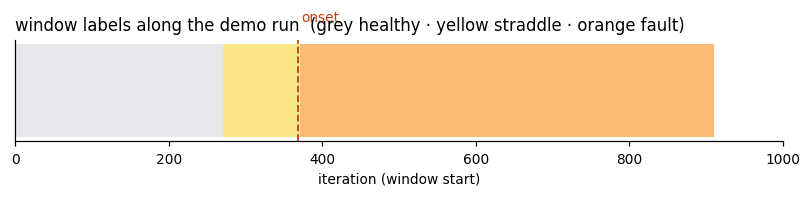

In [8]:
W = 100
starts = list(range(1, 1000 - W + 2, 10))
labels = pd.DataFrame([{"start": s, "end": s + W, **dict(zip(("label", "fault_frac"),
                        mb._window_label(DEMO_SCENARIO, s, s + W, truth)))} for s in starts])
print(labels["label"].value_counts().to_dict())

fig, ax = plt.subplots(figsize=(9, 1.2))
colour = {"healthy": "#e5e7eb", "straddle": "#fde68a", DEMO_SCENARIO: "#fdba74"}
for _, r in labels.iterrows():
    ax.barh(0, 10, left=r["start"], color=colour[r["label"]], height=0.6)
ax.axvline(truth["onset"], color=A, lw=1.2, ls="--"); ax.text(truth["onset"] + 5, 0.45, "onset", color=A)
ax.set_yticks([]); ax.set_xlabel("iteration (window start)"); ax.set_xlim(0, 1000)
ax.set_title("window labels along the demo run  (grey healthy · yellow straddle · orange fault)", loc="left")
plt.show()

## 4. Feature engineering: make the physics dimensionless

`RunTables` pivots each table once so a window is a row slice. Every feature is a ratio, a fraction, a
dispersion, a counter delta per byte, or a deviation from the fleet or rack median. That is what lets one
model cover three meshes whose iteration times differ 20×. Windows are defined in **iterations**, not
seconds, so a window holds ~4 device samples on the coarse mesh and ~80 on the fine one; all features are
therefore count-invariant (means, maxima, fractions, last−first), never sums.

In [9]:
t0 = time.perf_counter()
rt = mb.RunTables(demo.frames)
feat = pd.DataFrame([{"start": s, **rt.window_features(s, s + W)} for s in starts]).merge(labels, on="start")
print(f"{len(feat)} windows x {len(mb._cols(feat))} features in {time.perf_counter() - t0:.1f}s")
feat_cols = mb._cols(feat)
pd.Series(feat_cols).groupby(pd.Series(feat_cols).str.split("_").str[0]).apply(list).to_dict()

91 windows x 50 features in 3.0s


{'agg': ['agg_oversub_max',
  'agg_uplink_util_max',
  'agg_queue_max',
  'agg_congested_frac'],
 'gpu': ['gpu_occ_mean',
  'gpu_util_occ_gap',
  'gpu_occ_min_rel',
  'gpu_clock_min_rel',
  'gpu_power_cv',
  'gpu_rack_temp_drift',
  'gpu_rack_temp_rise',
  'gpu_temp_max_minus_med',
  'gpu_throttled_frac',
  'gpu_throttle_thermal_frac',
  'gpu_throttle_reliab_frac'],
 'job': ['job_iter_cv',
  'job_iter_slope_rel',
  'job_spread_rel',
  'job_sync_rel',
  'job_halo_over_compute',
  'job_halo_max_rel',
  'job_compute_max_rel',
  'job_output_duty'],
 'nic': ['nic_err_rate', 'nic_err_max', 'nic_drop_rate', 'nic_tx_cv'],
 'node': ['node_io_pressure_mean',
  'node_io_pressure_max',
  'node_cpu_pressure_mean',
  'node_mem_pressure_mean'],
 'port': ['port_down_frac',
  'port_down_max_domain',
  'port_err_rate_max_domain',
  'port_drop_rate_max_domain',
  'port_util_max',
  'port_queue_max'],
 'rank': ['rank_pace_top1',
  'rank_pace_top3',
  'rank_pace_entropy',
  'rank_excess_max_mean',
  'rank_

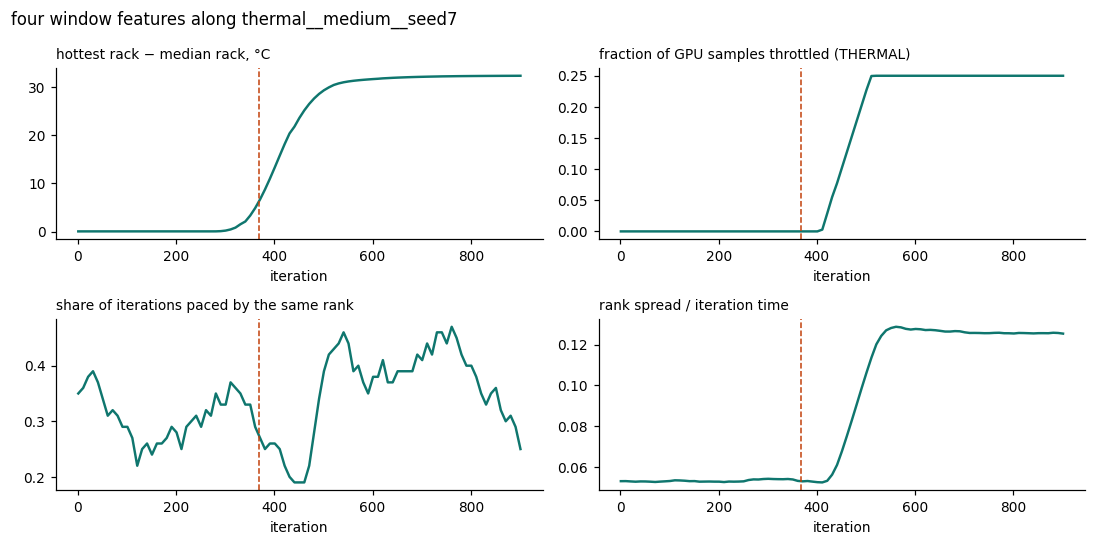

In [10]:
show = [("gpu_rack_temp_drift", "hottest rack − median rack, °C"),
        ("gpu_throttle_thermal_frac", "fraction of GPU samples throttled (THERMAL)"),
        ("rank_pace_top1", "share of iterations paced by the same rank"),
        ("job_spread_rel", "rank spread / iteration time")]
fig, axes = plt.subplots(2, 2, figsize=(10, 5)); axes = axes.ravel()
for ax, (col, title) in zip(axes, show):
    ax.plot(feat["start"], feat[col], color=B, lw=1.6)
    ax.axvline(truth["onset"], color=A, ls="--", lw=1); ax.set_title(title, loc="left", fontsize=9)
    ax.set_xlabel("iteration")
fig.suptitle(f"four window features along {demo.run_id}", x=0.01, ha="left"); fig.tight_layout(); plt.show()

The same physics, expressed per entity. Entity features are deviations from the rack and fleet median,
so the faulty rack's 32 GPUs stand out as a block while healthy GPUs sit near zero.

In [11]:
s_post = truth["onset"] + 200
g = rt.gpu_features(s_post, s_post + W)
g["in_target_rack"] = g["rack_id"] == truth["rack"]
g.groupby("in_target_rack")[["e_temp_minus_fleet_med", "e_rack_med_temp_minus_fleet_med",
                             "e_clock_rel_fleet_med", "e_throttled_frac", "e_pace_duty"]].mean().round(3)

,e_temp_minus_fleet_med,e_rack_med_temp_minus_fleet_med,e_clock_rel_fleet_med,e_throttled_frac,e_pace_duty
in_target_rack,,,,,
False,-0.103,-0.121,0.000,0.0,0.000
True,31.306,31.342,-0.091,1.0,0.031


## 5. The full dataset

The training matrix is 6 scenarios × 3 meshes × 10 seeds × 2 allocations (full cluster and a re-drawn
subset) = 360 runs (~1.4 GB, ~40 minutes to simulate, ~25 minutes to window). The cell below only runs the
pipeline when the cached dataset is missing.

In [12]:
cached = (RUNS / "ml" / "features_rack.parquet").exists()
print("cached dataset present:", cached)
if not cached:
    args = mb.build_parser().parse_args(["all", "--runs-dir", str(RUNS)])
    mb.generate(args)          # 360 simulations, targets and onsets re-drawn per seed
    mb.build_features(args)    # windows at stride 10; every 25th start is a training window

cached dataset present: True


In [13]:
win = pd.read_parquet(RUNS / "ml" / "features_window.parquet")
labelled = win[win["train_stride"] & (win["label"] != "straddle")].reset_index(drop=True)
print(f"{win['run_id'].nunique()} runs, {len(win)} windows at stride 10, {len(labelled)} labelled training windows")
print("runs by allocation:", labelled.groupby("alloc")["run_id"].nunique().to_dict())
labelled.groupby(["mesh", "label"]).size().unstack(fill_value=0)[mb.CLASSES]

360 runs, 32760 windows at stride 10, 6366 labelled training windows
runs by allocation: {'full': 180, 'nodes8_packed': 42, 'rack1_packed': 36, 'racks2_packed': 34, 'scatter32': 39, 'scatter64': 29}


label,healthy,straggler,network_domain,thermal,gpu_degradation,phase_change
mesh,,,,,,
coarse,920,380,198,230,192,202
fine,920,380,198,230,192,202
medium,920,380,198,230,192,202


## 6. Split by seed, and prove there is no leak

Windows overlap and neighbours are near-copies, so a random row split would score near 1.0 and mean
nothing. Every result here holds out **whole seeds**: 3, 4, 8 and 9, the script's `DEFAULT_TEST_SEEDS`, four of the ten.

`mb._cols` drops the label columns, every entity id, the window position, the events-derived columns and
`job_ckpt_rel` (checkpoint time over iteration time, which identifies the mesh rather than the phase).
`throttled`/`throttle_reason` are kept: they are the device's own self-report, not a label.

The sanity check: shuffle the training labels, retrain, score the held-out seeds. Chance for six classes
is about 0.17; anything well above that would mean a leak survived.

In [14]:
cols = mb._cols(labelled)
test_seeds = set(mb.DEFAULT_TEST_SEEDS)
SEED_HOLDOUT = "seeds " + ", ".join(map(str, sorted(test_seeds)))
tr, te = labelled[~labelled["seed"].isin(test_seeds)], labelled[labelled["seed"].isin(test_seeds)]
print(f"{len(cols)} features; train {len(tr)} windows (seeds {sorted(set(tr.seed))}), test {len(te)} (seeds {sorted(test_seeds)})")
print("excluded as leakage or identity:", sorted(mb.META | mb.WALLTIME_RATIOS))

perm = tr.copy(); perm["label"] = np.random.default_rng(0).permutation(perm["label"].to_numpy())
s_perm, _ = mb._fit_eval(perm, te, cols)
print(f"\nmacro-F1 with permuted labels: {s_perm['macro_f1']:.3f}  (chance ≈ {1 / 6:.2f})")

50 features; train 3816 windows (seeds [1, 2, 5, 6, 7, 42]), test 2550 (seeds [3, 4, 8, 9])
excluded as leakage or identity: ['alloc', 'end', 'fault_frac', 'gpu_id', 'job_ckpt_rel', 'label', 'mesh', 'n_ranks', 'node_id', 'placement', 'positive', 'rack_id', 'run_id', 'scenario', 'seed', 'start', 't0', 't1', 'train_stride']



macro-F1 with permuted labels: 0.190  (chance ≈ 0.17)


## 7. Train and evaluate on held-out seeds

Primary model: `HistGradientBoostingClassifier` (NaN-tolerant, class-weighted). Baseline: logistic
regression on the same features. Both fit in seconds.

In [15]:
t0 = time.perf_counter()
s_hgb, hgb = mb._fit_eval(tr, te, cols)
s_lr, lr = mb._fit_eval(tr, te, cols, mb._logreg())
print(f"fitted both in {time.perf_counter() - t0:.1f}s")
pd.DataFrame({"gradient-boosted trees": s_hgb["per_class_f1"], "logistic regression": s_lr["per_class_f1"]}).T \
    .assign(macro_f1=[s_hgb["macro_f1"], s_lr["macro_f1"]], false_alarm=[s_hgb["false_alarm_rate"], s_lr["false_alarm_rate"]]).round(3)

fitted both in 2.4s


,healthy,straggler,network_domain,thermal,gpu_degradation,phase_change,macro_f1,false_alarm
gradient-boosted trees,1.000,1.0,1.0,1.000,1.0,1.0,1.000,0.000
logistic regression,0.999,1.0,1.0,0.995,1.0,1.0,0.999,0.001


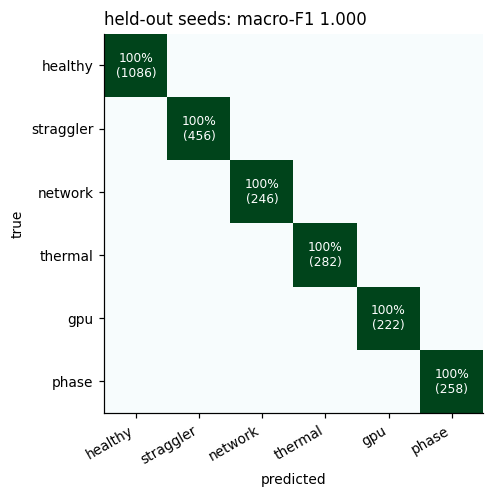

In [16]:
cm = np.array(s_hgb["confusion"]); counts = np.array(s_hgb["confusion_counts"])
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.imshow(cm, cmap="BuGn", vmin=0, vmax=1)
short = ["healthy", "straggler", "network", "thermal", "gpu", "phase"]
ax.set_xticks(range(6), short, rotation=30, ha="right"); ax.set_yticks(range(6), short)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
for i in range(6):
    for j in range(6):
        if counts[i, j]:
            ax.text(j, i, f"{100 * cm[i, j]:.0f}%\n({counts[i, j]})", ha="center", va="center",
                    color="white" if cm[i, j] > 0.55 else "black", fontsize=8)
ax.set_title(f"held-out seeds: macro-F1 {s_hgb['macro_f1']:.3f}", loc="left"); plt.tight_layout(); plt.show()

The same held-out windows, split by the job's allocation.

In [17]:
pd.DataFrame({a: {"windows": len(g), "trees macro-F1": mb._scores(g["label"], hgb.predict(g[cols]))["macro_f1"],
                  "linear macro-F1": mb._scores(g["label"], lr.predict(g[cols]))["macro_f1"]}
              for a, g in te.groupby("alloc")}).T.round(3)

,windows,trees macro-F1,linear macro-F1
full,1275.0,1.000,0.999
nodes8_packed,266.0,1.000,1.000
rack1_packed,227.0,0.833,0.825
racks2_packed,244.0,1.000,1.000
scatter32,343.0,1.000,1.000
scatter64,195.0,1.000,1.000


Leave-one-seed-out cross-validation gives the spread across seeds rather than one split.

In [18]:
from sklearn.model_selection import GroupKFold
folds = []
for tri, tei in GroupKFold(n_splits=labelled["seed"].nunique()).split(labelled, groups=labelled["seed"]):
    s, _ = mb._fit_eval(labelled.iloc[tri], labelled.iloc[tei], cols)
    folds.append({"held-out seed": int(labelled.iloc[tei]["seed"].iloc[0]), "macro_f1": s["macro_f1"]})
folds = pd.DataFrame(folds); print(f"mean {folds.macro_f1.mean():.3f} ± {folds.macro_f1.std(ddof=0):.3f}"); folds.round(3)

mean 0.998 ± 0.006


,held-out seed,macro_f1
0,3,1.000
1,42,1.000
2,9,1.000
3,8,1.000
4,7,1.000
5,6,0.981
6,5,0.999
7,4,1.000
8,2,1.000
9,1,1.000


## 8. Transfer: hold out a whole mesh

The closest thing the simulator offers to a domain-shift test. A different cell count, a different
iteration time, a different number of samples per window. Trees and the linear model disagree here, and
the reason is instructive: a split threshold learned inside one mesh's healthy range says nothing about
values outside it, whereas a linear boundary on dimensionless features extends.

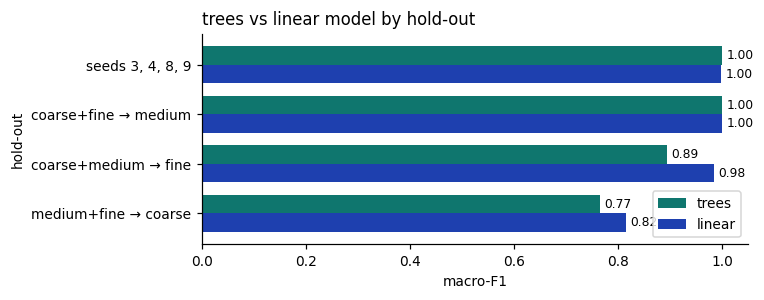

In [19]:
splits = [("coarse+fine → medium", ["coarse", "fine"], "medium"),
          ("coarse+medium → fine", ["coarse", "medium"], "fine"),
          ("medium+fine → coarse", ["medium", "fine"], "coarse")]
rows = [{"hold-out": SEED_HOLDOUT, "trees": s_hgb["macro_f1"], "linear": s_lr["macro_f1"]}]
per_class = {}
for name, train_m, test_m in splits:
    a, b = labelled[labelled["mesh"].isin(train_m)], labelled[labelled["mesh"] == test_m]
    st, _ = mb._fit_eval(a, b, cols); sl, _ = mb._fit_eval(a, b, cols, mb._logreg())
    rows.append({"hold-out": name, "trees": st["macro_f1"], "linear": sl["macro_f1"]})
    per_class[name] = {"trees": st["per_class_f1"], "linear": sl["per_class_f1"]}
mesh = pd.DataFrame(rows).set_index("hold-out")
ax = mesh.plot.barh(color=[B, C], figsize=(7, 2.8), width=0.75); ax.invert_yaxis(); ax.set_xlim(0, 1.05)
ax.set_xlabel("macro-F1"); ax.set_title("trees vs linear model by hold-out", loc="left")
for c in ax.containers: ax.bar_label(c, fmt="%.2f", padding=3, fontsize=8)
plt.tight_layout(); plt.show()

In [20]:
worst = mesh.drop(SEED_HOLDOUT)["trees"].idxmin()
print("per-class F1 on the hardest hold-out:", worst)
pd.DataFrame(per_class[worst]).round(2)

per-class F1 on the hardest hold-out: medium+fine → coarse


,trees,linear
healthy,0.39,0.65
straggler,0.49,0.74
network_domain,1.00,1.00
thermal,0.71,0.84
gpu_degradation,1.00,0.67
phase_change,1.00,0.99


### Train on full-cluster jobs only, test on subset jobs

The second domain-shift test. Every subset window is unseen here, across all seeds: a 32-rank job on one
rack has no cross-rack halo traffic at all, so a network fault on its own leaf shows up only in the switch
counters.

In [21]:
full, subset = labelled[labelled["alloc"] == "full"], labelled[labelled["alloc"] != "full"]
s_t, m_t = mb._fit_eval(full, subset, cols); s_l, m_l = mb._fit_eval(full, subset, cols, mb._logreg())
print(f"train {len(full)} full-allocation windows -> test {len(subset)} subset windows: trees {s_t['macro_f1']:.3f}, linear {s_l['macro_f1']:.3f}")
by_profile = pd.DataFrame({a: {"windows": len(g), "trees": mb._scores(g["label"], m_t.predict(g[cols]))["macro_f1"],
                               "linear": mb._scores(g["label"], m_l.predict(g[cols]))["macro_f1"]}
                           for a, g in subset.groupby("alloc")}).T
display(by_profile.round(3))
pd.DataFrame({"trees": s_t["per_class_f1"], "linear": s_l["per_class_f1"]}).round(2)

train 3183 full-allocation windows -> test 3183 subset windows: trees 0.829, linear 0.917


,windows,trees,linear
nodes8_packed,741.0,0.879,0.997
rack1_packed,634.0,0.638,0.541
racks2_packed,592.0,0.903,0.998
scatter32,699.0,0.807,0.850
scatter64,517.0,0.845,0.998


,trees,linear
healthy,0.79,0.92
straggler,0.98,1.00
network_domain,0.49,0.82
thermal,0.71,0.93
gpu_degradation,1.00,1.00
phase_change,1.00,0.83


The **medium+fine → coarse** case is hard for both models: the coarse mesh carries a genuine 4 % load
imbalance on healthy hardware, so "one rank always paces the barrier" is normal there and a straggler
signature elsewhere. A real fleet has the same problem between applications: the healthy baseline is per
workload.

## 9. Ablations: which tables carry the signal?

Remove a feature family, retrain, score the held-out seeds. Two additions show the leakage risk of
mesh identifiers: absolute iteration time and the checkpoint-to-iteration ratio.

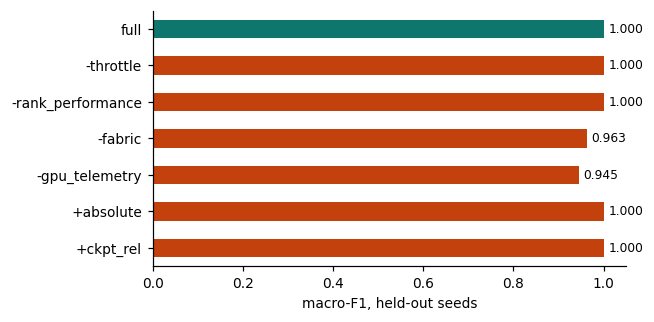

In [22]:
rows = []
for name, drop in mb.ABLATIONS.items():
    s, _ = mb._fit_eval(tr, te, mb._cols(labelled, drop=drop)); rows.append((name, s["macro_f1"]))
s, _ = mb._fit_eval(tr, te, mb._cols(labelled, absolute=True)); rows.append(("+absolute", s["macro_f1"]))
s, _ = mb._fit_eval(tr, te, cols + sorted(mb.WALLTIME_RATIOS)); rows.append(("+ckpt_rel", s["macro_f1"]))
abl = pd.Series(dict(rows))
ax = abl.plot.barh(color=[B] + [A] * (len(abl) - 1), figsize=(6, 3)); ax.invert_yaxis(); ax.set_xlim(0, 1.05)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3, fontsize=8); ax.set_xlabel("macro-F1, held-out seeds")
plt.tight_layout(); plt.show()

Removing any one table costs almost nothing: the six signatures are redundant across tables. On a fleet the
job-timing tables are the ones most often missing, so `-rank_performance` is the ablation to watch.

## 10. Streaming inference and time to detect

The same model scores every stride-10 window of a held-out run as it progresses. Detection is the first
window ending after the onset whose class is right for two consecutive windows. The rule set, by
contrast, answers once per run after the last 30 % of it.

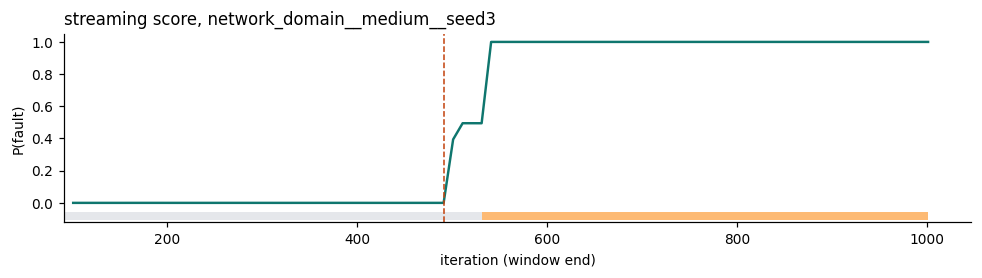

In [23]:
stream = win[win["seed"].isin(test_seeds)].copy()
stream["pred"] = hgb.predict(stream[cols])
proba = hgb.predict_proba(stream[cols])
fault_idx = [list(hgb.classes_).index(c) for c in mb.FAULT_CLASSES]
stream["p_fault"] = proba[:, fault_idx].sum(axis=1)

truths = {rid: mb._run_truth(RUNS, rid) for rid in stream["run_id"].unique()}   # reads 36 runs

rid = "network_domain__medium__seed3"          # the full-allocation twin; subset runs live under alloc_*/
g = stream[stream["run_id"] == rid].sort_values("start")
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(g["end"], g["p_fault"], color=B, lw=1.6)
for _, r in g.iterrows():
    ax.barh(-0.08, 10, left=r["end"] - 10, height=0.05, color="#e5e7eb" if r["pred"] == "healthy" else "#fdba74")
ax.axvline(truths[rid]["onset"], color=A, ls="--", lw=1); ax.set_ylim(-0.12, 1.05)
ax.set_xlabel("iteration (window end)"); ax.set_ylabel("P(fault)"); ax.set_title(f"streaming score, {rid}", loc="left")
plt.tight_layout(); plt.show()

In [24]:
ttd = []
for rid, g in stream.groupby("run_id"):
    scenario = g["scenario"].iloc[0]
    if scenario == "healthy":
        continue
    g = g.sort_values("end"); onset = truths[rid]["onset"] or 1
    cand = g[g["end"] >= onset]; hit = (cand["pred"] == scenario).to_numpy()
    det = next((cand.iloc[i] for i in range(len(hit) - 1) if hit[i] and hit[i + 1]), None)
    onset_t = float(np.interp(onset, g["start"], g["t0"]))
    ttd.append({"scenario": scenario, "mesh": g["mesh"].iloc[0], "detected": det is not None,
                "iterations": int(det["end"] - onset) if det is not None else None,
                "seconds": float(det["t1"] - onset_t) if det is not None else None})
ttd = pd.DataFrame(ttd)
fa = stream[stream["scenario"].isin(["healthy", "phase_change"])].groupby("scenario")["pred"].apply(lambda p: p.isin(mb.FAULT_CLASSES).mean())
print("false-alarm rate per window:", fa.round(3).to_dict())
ttd.groupby(["scenario", "mesh"]).agg(detected=("detected", "sum"), n=("detected", "size"),
                                      median_iterations=("iterations", "median"), median_seconds=("seconds", "median")).round(1)

false-alarm rate per window: {'healthy': 0.0, 'phase_change': 0.0}


detected  n  median_iterations  median_seconds
scenario        mesh                                                  
gpu_degradation coarse         8  8               40.5             2.1
                fine           8  8               39.5            50.1
                medium         8  8               38.0            11.6
network_domain  coarse         8  8               37.0             2.0
                fine           8  8               50.0            47.2
                medium         8  8               50.0            11.9
phase_change    coarse         8  8               63.0             3.0
                fine           8  8               63.0            67.1
                medium         8  8               63.0            16.1
straggler       coarse         8  8              100.0             5.1
                fine           8  8              100.0           124.5
                medium         8  8              100.0            29.7
thermal         coarse         8  8               76.5             3.6
                fine           8  8               40.5            45.5
                medium         8  8               54.0            13.7

Latency is partly physics: the cooling fault ramps over 60 iterations and the die follows with a 20 s
time constant, and a window only carries a fault's mean signature once most of it lies after the onset.

## 11. Run-level verdicts: learned model vs the rule set

`metrics.diagnose` runs on every simulated run and stores its verdict in `summary.json`. It never saw
these randomised targets and onsets, so this is its first out-of-sample test too. The learned model's
windows are rolled up with one policy: the most frequent non-healthy class if it appears in ≥ 3 windows.

In [25]:
rows = []
for rid, g in stream.groupby("run_id"):
    scenario = g["scenario"].iloc[0]; truth = truths[rid]
    rows.append({"scenario": scenario, "run_id": rid, "ML": mb._rollup(g["pred"]),
                 "rules": mb._rules_class(truth["diagnosis"]),
                 "rules localised": mb._rules_localised(truth["diagnosis"], scenario, truth)})
runs = pd.DataFrame(rows)
runs["ML ok"] = runs["ML"] == runs["scenario"]; runs["rules ok"] = runs["rules"] == runs["scenario"]
runs["alloc"] = runs["run_id"].map(lambda r: r.split("/")[0].replace("alloc_", "") if "/" in r else "full")
print(f"ML {runs['ML ok'].sum()}/{len(runs)}   rules {runs['rules ok'].sum()}/{len(runs)}")
display(runs.groupby("scenario")[["ML ok", "rules ok"]].sum())
runs.groupby("alloc")[["ML ok", "rules ok"]].agg(["sum", "size"])

ML 144/144   rules 139/144


,ML ok,rules ok
scenario,,
gpu_degradation,24,24
healthy,24,23
network_domain,24,24
phase_change,24,20
straggler,24,24
thermal,24,24


ML ok      rules ok     
                sum size      sum size
alloc                                 
full             72   72       72   72
nodes8_packed    15   15       15   15
rack1_packed     13   13       12   13
racks2_packed    14   14       14   14
scatter32        19   19       15   19
scatter64        11   11       11   11

## 12. Localisation: which GPU, which rack

A second model scores every (window, GPU) and (window, rack) from fleet-relative features, with the
injected entity as the label. It is consumed as a ranked list, so the metrics are ranking metrics:
precision@1 and per-window AUROC. Unsupervised scores are fitted on healthy rows only, the realistic
starting point on a fleet with few labelled incidents.

In [26]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

gpu = pd.read_parquet(RUNS / "ml" / "features_gpu.parquet"); gcols = mb._cols(gpu)
gtr, gte = gpu[~gpu["seed"].isin(test_seeds)], gpu[gpu["seed"].isin(test_seeds)].copy()
t0 = time.perf_counter()
ghgb = mb._hgb().fit(gtr[gcols], gtr["positive"].astype(int)); gte["s_hgb"] = ghgb.predict_proba(gte[gcols])[:, 1]
gh = gtr[gtr["label"] == "healthy"]; gh = gh.sample(min(len(gh), 60000), random_state=0)
gimp = SimpleImputer(strategy="median").fit(gh[gcols]); Gh, Gt = gimp.transform(gh[gcols]), gimp.transform(gte[gcols])
gte["s_iforest"] = -IsolationForest(n_estimators=200, random_state=0).fit(Gh).score_samples(Gt)
gsc = StandardScaler().fit(Gh); gpca = PCA(n_components=0.95, random_state=0).fit(gsc.transform(Gh)); Zg = gsc.transform(Gt)
gte["s_pca"] = np.sqrt(((Zg - gpca.inverse_transform(gpca.transform(Zg))) ** 2).mean(axis=1))
print(f"{len(gtr)} training rows, {len(gte)} test rows, fitted in {time.perf_counter() - t0:.0f}s")
pd.concat({m: pd.DataFrame(mb._ranking_metrics(gte, f"s_{m}")).T for m in ("hgb", "iforest", "pca")}, axis=1).round(3)

341920 training rows, 226560 test rows, fitted in 15s


hgb                                       iforest                                            pca                                
                precision_at_1 precision_at_k auroc n_windows precision_at_1 precision_at_k  auroc n_windows precision_at_1 precision_at_k  auroc n_windows
gpu_degradation            1.0            1.0   1.0     222.0          1.000          1.000  1.000     222.0          1.000          1.000  1.000     222.0
straggler                  1.0            1.0   1.0     456.0          0.928          0.836  0.995     456.0          1.000          1.000  1.000     456.0
thermal                    1.0            1.0   1.0     272.0          0.904          0.788  0.911     272.0          0.945          0.936  0.933     272.0

In [27]:
sg = gte[(gte["label"] == "straggler") & (gte["alloc"] == "full")]; rid = sorted(sg["run_id"].unique())[0]
w = sg[(sg["run_id"] == rid)]; w = w[w["start"] == w["start"].iloc[len(w) // 2]]
print(f"one straggler window, {rid}, iterations {int(w['start'].iloc[0])}–{int(w['start'].iloc[0]) + W}: GPUs ranked by score")
w.sort_values("s_hgb", ascending=False)[["gpu_id", "s_hgb", "positive", "e_pace_duty", "e_wait_rel"]].head(6).round(3)

one straggler window, straggler__coarse__seed3, iterations 451–551: GPUs ranked by score


,gpu_id,s_hgb,positive,e_pace_duty,e_wait_rel
275282,r2n2g2,1.0,True,0.21,0.060
275217,r0n2g1,1.0,True,0.10,0.091
275229,r0n3g5,0.0,False,0.00,0.144
275259,r1n3g3,0.0,False,0.00,0.145
275279,r2n1g7,0.0,False,0.00,0.144
275226,r0n3g2,0.0,False,0.00,0.146


### Where the isolation forest goes blind

Rack-level scores for the network fault. The failed rack carries wildly out-of-range values (7 of 8
uplinks down, a drop rate thousands of times the background) yet the isolation forest never ranks it
first. The reason: those channels are **constant in healthy data**, so no tree ever splits on them, and
a value no tree splits on cannot be isolated. A reconstruction residual has no such blind spot.

In [28]:
rack = pd.read_parquet(RUNS / "ml" / "features_rack.parquet"); kcols = mb._cols(rack)
ktr, kte = rack[~rack["seed"].isin(test_seeds)], rack[rack["seed"].isin(test_seeds)].copy()
khgb = mb._hgb().fit(ktr[kcols], ktr["positive"].astype(int)); kte["s_hgb"] = khgb.predict_proba(kte[kcols])[:, 1]
kh = ktr[ktr["label"] == "healthy"]
kimp = SimpleImputer(strategy="median").fit(kh[kcols]); Kh, Kt = kimp.transform(kh[kcols]), kimp.transform(kte[kcols])
kte["s_iforest"] = -IsolationForest(n_estimators=200, random_state=0).fit(Kh).score_samples(Kt)
ksc = StandardScaler().fit(Kh); kpca = PCA(n_components=0.95, random_state=0).fit(ksc.transform(Kh)); Zk = ksc.transform(Kt)
kte["s_pca"] = np.sqrt(((Zk - kpca.inverse_transform(kpca.transform(Zk))) ** 2).mean(axis=1))

top1 = {}
for m in ("hgb", "iforest", "pca"):
    for scenario in ("thermal", "network_domain"):
        sub = kte[kte["label"] == scenario]
        top1[(scenario, m)] = np.mean([bool(x.loc[x[f"s_{m}"].idxmax(), "positive"]) for _, x in sub.groupby(["run_id", "start"])])
print("rack top-1 accuracy:"); display(pd.Series(top1).unstack().round(2))

nw = kte[kte["run_id"] == "network_domain__medium__seed3"]; nw = nw[nw["start"] == nw["start"].max()]
print("\nconstant-in-healthy channels:", [c for c in kcols if kh[c].std() == 0])
nw[["rack_id", "positive", "k_leaf_down_frac", "k_leaf_drop_rate", "k_leaf_oversub", "s_iforest", "s_pca", "s_hgb"]].round(3)

rack top-1 accuracy:


,hgb,iforest,pca
network_domain,1.0,0.26,1.00
thermal,1.0,1.00,0.91



constant-in-healthy channels: ['k_throttled_frac', 'k_leaf_down_frac', 'k_leaf_drop_rate', 'k_leaf_oversub']


,rack_id,positive,k_leaf_down_frac,k_leaf_drop_rate,k_leaf_oversub,s_iforest,s_pca,s_hgb
5880,r0,False,0.000,0.000,1.0,0.522,3.312,0.0
5881,r1,False,0.000,0.000,1.0,0.593,1.566,0.0
5882,r2,True,0.875,4882.812,8.0,0.506,2005.817,1.0
5883,r3,False,0.000,0.000,1.0,0.573,1.535,0.0


## 13. What the model learned

Permutation importance on the held-out seeds: shuffle one feature, measure the macro-F1 it costs.
Grouped by source table, then the top features per class.

27s


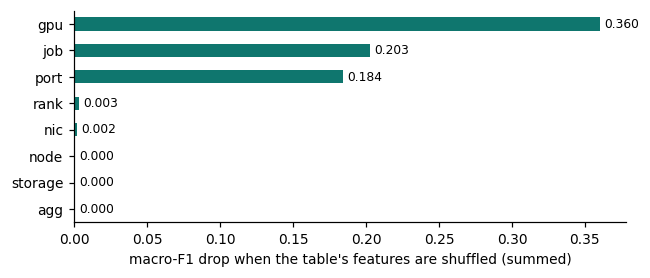

,1st,2nd,3rd
healthy,job_output_duty,port_down_frac,gpu_rack_temp_drift
straggler,gpu_throttle_reliab_frac,gpu_rack_temp_drift,rank_wait_min_rel
network_domain,port_down_frac,job_output_duty,gpu_rack_temp_drift
thermal,gpu_rack_temp_drift,job_output_duty,gpu_throttle_reliab_frac
gpu_degradation,gpu_throttle_reliab_frac,job_output_duty,port_down_frac
phase_change,job_output_duty,storage_write_lat_mean,storage_write_lat_max


In [29]:
t0 = time.perf_counter()
imp = mb._permutation_importance(hgb, te, cols, n_repeats=3)
print(f"{time.perf_counter() - t0:.0f}s")
by_table = pd.Series(imp["by_table"]).sort_values()
ax = by_table.plot.barh(color=B, figsize=(6, 2.6)); ax.set_xlabel("macro-F1 drop when the table's features are shuffled (summed)")
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3, fontsize=8); plt.tight_layout(); plt.show()
pd.DataFrame({c: [f for f, _ in v[:3]] for c, v in imp["top_per_class"].items()}, index=["1st", "2nd", "3rd"]).T

Every uplink, NIC and storage feature scores zero: halo dispersion across ranks already names the network
fault, and output duty the phase change. The model chose the job-timing channels over the fabric counters
because on this simulator they are redundant.

## 14. Unsupervised baselines: novelty is not fault

Fit on healthy training windows only, flag anything beyond the 95th percentile of healthy scores. The
isolation forest flags the output campaign in every window: the storage channel moved, so the window is
novel. Only labelled non-faults, or a rule that says "no hardware channel moved", tell the two apart.

AUROC for is-fault: isolation forest 0.750, PCA residual 0.943


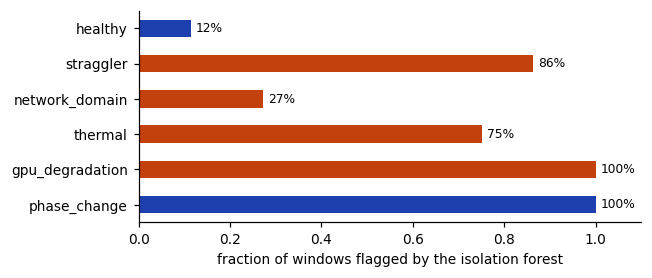

In [30]:
from sklearn.metrics import roc_auc_score
healthy_tr = tr[tr["label"] == "healthy"]
imp_w = SimpleImputer(strategy="median").fit(healthy_tr[cols]); Xh, Xt = imp_w.transform(healthy_tr[cols]), imp_w.transform(te[cols])
iso = IsolationForest(n_estimators=300, random_state=0).fit(Xh)
score = -iso.score_samples(Xt); thr = np.percentile(-iso.score_samples(Xh), 95)
sc = StandardScaler().fit(Xh); pca = PCA(n_components=0.95, random_state=0).fit(sc.transform(Xh)); Zt = sc.transform(Xt)
resid = np.sqrt(((Zt - pca.inverse_transform(pca.transform(Zt))) ** 2).mean(axis=1))
y_fault = te["label"].isin(mb.FAULT_CLASSES).to_numpy()
print(f"AUROC for is-fault: isolation forest {roc_auc_score(y_fault, score):.3f}, PCA residual {roc_auc_score(y_fault, resid):.3f}")
flag = pd.Series({c: (score[(te["label"] == c).to_numpy()] > thr).mean() for c in mb.CLASSES})
ax = flag.plot.barh(color=[C if c in ("healthy", "phase_change") else A for c in flag.index], figsize=(6, 2.6))
ax.invert_yaxis(); ax.set_xlim(0, 1.1); ax.bar_label(ax.containers[0], fmt=lambda v: f"{100 * v:.0f}%", padding=3, fontsize=8)
ax.set_xlabel("fraction of windows flagged by the isolation forest"); plt.tight_layout(); plt.show()

## 15. Reproducing everything from the command line

The whole pipeline is one script; the deck is rendered from its metrics:

```bash
python scripts/ml_baseline.py --runs-dir runs_ml all    # generate → features → train, seeds 42 1 2 3 4 5 6 7 8 9
python scripts/ml_deck.py                                                   # ML_FAULT_DIAGNOSIS.html from runs_ml/ml/metrics.json
```

Three findings worth carrying forward:

- **Checkpoint time over iteration time is a mesh identifier**, not a phase signal. Dropping it fixed
  the only in-distribution confusion. Fleet features need the same scrutiny: anything that scales with
  wall time rather than with work will encode the application.
- **Trees do not extrapolate.** With dimensionless features, a linear model transfers to an unseen
  workload where trees fall apart. Use a linear or monotone-constrained model as the default and trees as
  the in-distribution refinement.
- **An isolation forest cannot see a channel that never moves in healthy data.** Distance-based scores
  (reconstruction residual, robust z-scores) do not share that blind spot; a fleet detector should carry one.
- **Normalise against the job, not the cluster.** Idle GPUs are the most common thing in a fleet's telemetry;
  fleet-relative features must be computed over the devices the job occupies, or every subset job looks faulty.